# Notebook 02: Chunking Benchmark

This notebook compares chunk token-size distributions for four main chunking strategies on a single paper.

In [2]:
from pathlib import Path
import sys

from IPython.display import display
import matplotlib.pyplot as plt
import nltk
import pandas as pd

repo_root = Path.cwd().resolve()
if not (repo_root / "app").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from app.ingestion.arxiv_loader import ArxivLoader
from app.ingestion.chunkers import ChunkInput, ChunkerFactory
from app.ingestion.pdf_parser import PDFParser

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

c:\Users\Aymen\Desktop\ArXiv\arxiv-rag-research-assistant\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [3]:
query = "1706.03762"
loader = ArxivLoader(raw_dir=str(repo_root / "data" / "raw"))
papers = loader.fetch_papers(query=query, max_results=1)

if not papers:
    raise RuntimeError("No papers were returned by ArxivLoader.")

paper = papers[0]
parsed = PDFParser().parse(paper["pdf_path"])

chunk_input = ChunkInput(
    arxiv_id=paper["arxiv_id"],
    title=paper["title"],
    authors=paper["authors"],
    parsed=parsed,
)

chunkers = {
    "recursive": ChunkerFactory.get("recursive", chunk_size=800, chunk_overlap=100),
    "sentence": ChunkerFactory.get("sentence", sentences_per_chunk=5),
    "page": ChunkerFactory.get("page"),
    "token": ChunkerFactory.get("token", chunk_size=400, overlap=50),
}

rows = []
for strategy_name, chunker in chunkers.items():
    docs = chunker.chunk(chunk_input)
    for doc in docs:
        rows.append(
            {
                "strategy": strategy_name,
                "chunk_tokens": int(doc.metadata.get("token_count", 0)),
            }
        )

dist_df = pd.DataFrame(rows)
summary = (
    dist_df.groupby("strategy")["chunk_tokens"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
    .reset_index()
)

display(summary)

,strategy,count,mean,median,min,max
0,page,20,598.25,605.0,41,838
1,recursive,81,160.95,153.0,30,279
2,sentence,70,171.37,155.5,61,357
3,token,35,391.06,400.0,84,402


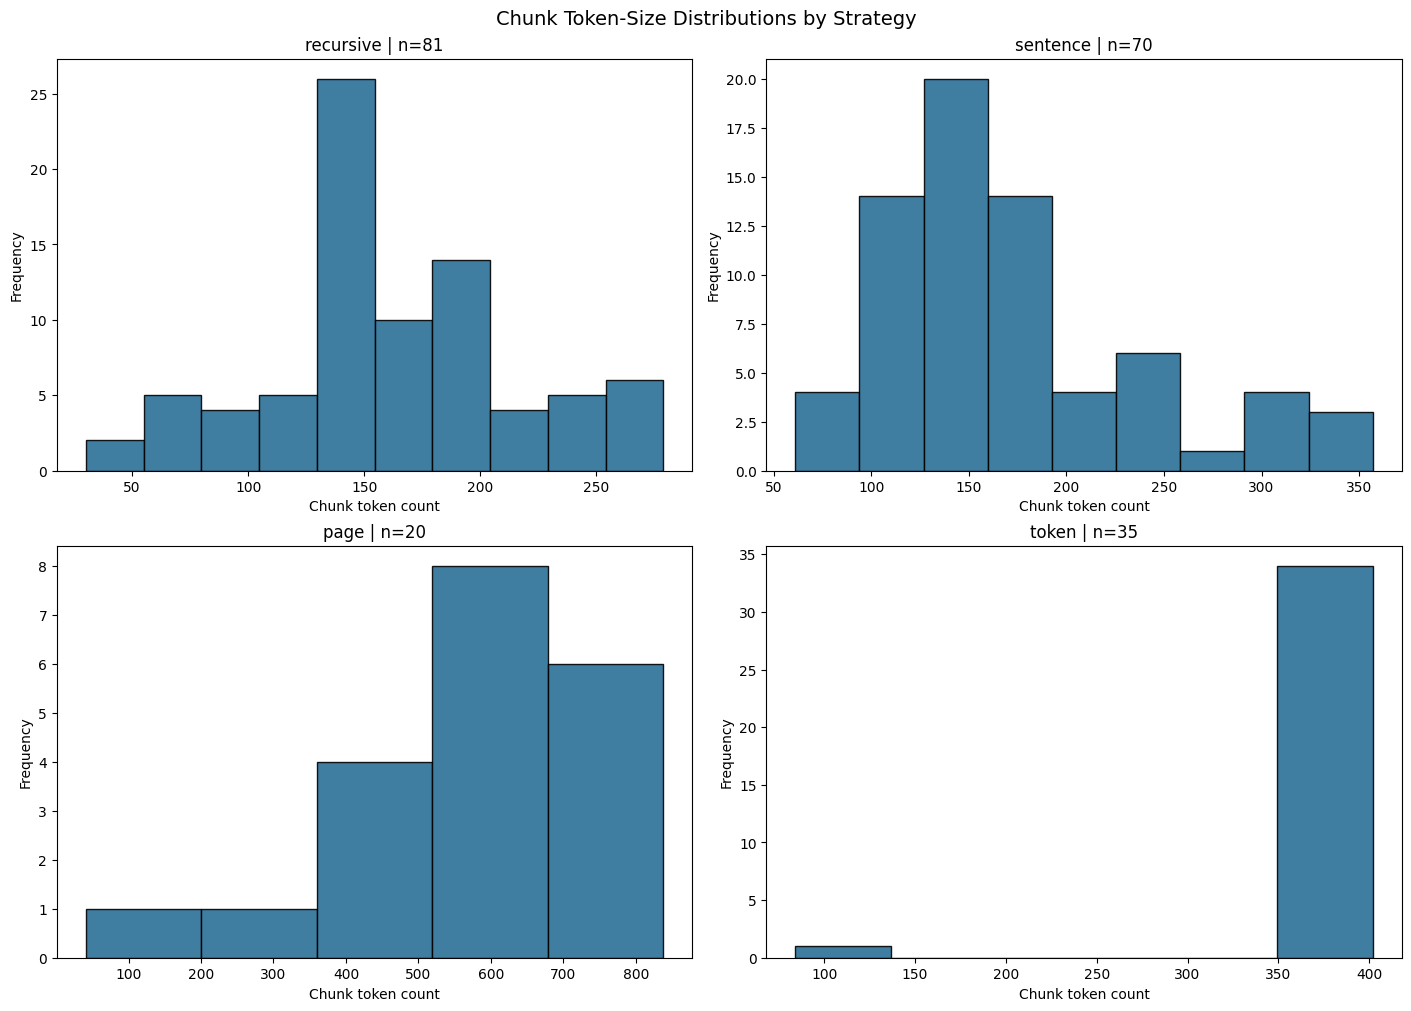

In [4]:
strategies = list(chunkers.keys())
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

for ax, strategy in zip(axes.flat, strategies):
    values = dist_df.loc[dist_df["strategy"] == strategy, "chunk_tokens"]
    if values.empty:
        ax.set_title(f"{strategy} (no chunks)")
        ax.axis("off")
        continue

    bins = min(20, max(5, int(values.shape[0] ** 0.5) + 1))
    ax.hist(values, bins=bins, color="#2A6F97", alpha=0.9, edgecolor="black")
    ax.set_title(f"{strategy} | n={values.shape[0]}")
    ax.set_xlabel("Chunk token count")
    ax.set_ylabel("Frequency")

fig.suptitle("Chunk Token-Size Distributions by Strategy", fontsize=14)
plt.show()